# GERT Historical Lab — reproduce a grid-risk calculation by hand

This notebook walks through the **GERT Historical Lab**, a 15-minute teaching exercise built on **216 hours of public ERCOT (Texas grid) load observations** — three 72-hour windows from 2021 and 2023.

You set two assumptions (available capacity in MW, uniform load reduction in %), do the arithmetic yourself on a few rows, and then let the notebook check your answers against the full 216-hour computation.

**Honest framing:** every number here is counterfactual arithmetic on recorded load — not a forecast. The lab's probabilistic model (v1.4) was publicly rejected for production after missing its predeclared calibration tolerance. The point of the exercise is to make the assumptions behind a grid-risk number visible.

In [1]:
# 0. Setup — nothing to install.
# This notebook uses only packages preinstalled in Colab (pandas, numpy, matplotlib),
# so "Runtime > Run all" works on a fresh runtime with no extra steps.
import pandas as pd
import numpy as np
import matplotlib
print("pandas", pd.__version__, "| numpy", np.__version__, "| matplotlib", matplotlib.__version__)

pandas 3.0.6 | numpy 2.5.3 | matplotlib 3.11.2


## 1. Load the data

The dataset lives on the Hugging Face Hub (public, MIT license) and is also archived on Zenodo (DOI 10.5281/zenodo.22975251). We read the CSV straight from the Hub — no local files needed.

In [2]:
DATA_URL = "https://huggingface.co/datasets/DresdenG/gert-historical-lab/resolve/main/data/historical-load.csv"

df = pd.read_csv(DATA_URL)
print(f"rows: {len(df)} | columns: {list(df.columns)}")
print()
print("hours per case:")
print(df["case_id"].value_counts().to_string())
print()
for case, g in df.groupby("case_id"):
    print(f"{case}: {g['interval_start'].min()} -> {g['interval_start'].max()}")
print()
print(df.head(3).to_string(index=False))

rows: 216 | columns: ['case_id', 'interval_start', 'recorded_load_mw', 'source_archive_sha256']

hours per case:
case_id
summer-2023    72
spring-2023    72
winter-2021    72

spring-2023: 2023-04-10T00:00:00-05:00 -> 2023-04-12T23:00:00-05:00
summer-2023: 2023-08-09T00:00:00-05:00 -> 2023-08-11T23:00:00-05:00
winter-2021: 2021-02-14T00:00:00-06:00 -> 2021-02-16T23:00:00-06:00

    case_id            interval_start  recorded_load_mw                                            source_archive_sha256
summer-2023 2023-08-09T00:00:00-05:00         63272.123 34e7067d3273f56be42ce469e23747cff0db736d668519070ad63674c3ddecd4
summer-2023 2023-08-09T01:00:00-05:00         60568.974 34e7067d3273f56be42ce469e23747cff0db736d668519070ad63674c3ddecd4
summer-2023 2023-08-09T02:00:00-05:00         58453.380 34e7067d3273f56be42ce469e23747cff0db736d668519070ad63674c3ddecd4


## 2. The arithmetic

For each hour, with recorded load $L$ (MW), assumed capacity $C$ (MW), and uniform reduction $r$ (%):

$$\text{adjusted} = L \times (1 - r/100), \qquad \text{gap} = \max(0, \text{adjusted} - C)$$

**Gap energy (MWh)** = sum of hourly gaps. Each row is one hour, so MW x 1 h = MWh.

Two things are *observed* (the recorded load); two things are *assumed* (capacity, reduction). The exercise is about seeing how much the assumptions move the answer.

In [3]:
CAPACITY = 80_000  # MW -- an assumption, not a measured value

def case_metrics(loads, capacity, reduction_pct):
    """Return (hours above capacity, gap energy in MWh)."""
    adjusted = loads * (1 - reduction_pct / 100)
    gap = (adjusted - capacity).clip(lower=0)
    return int((gap > 0).sum()), float(gap.sum())

summer = df[df["case_id"] == "summer-2023"].reset_index(drop=True)
loads = summer["recorded_load_mw"]

print(f"Summer 2023 case (Aug 9-11): {len(summer)} hourly rows, peak {loads.max():,.0f} MW")
print(f"Assumed capacity: {CAPACITY:,} MW\n")
print(f"{'reduction':>9} | {'hours above capacity':>20} | {'gap energy (MWh)':>16}")
for r in (0, 5, 10):
    h, e = case_metrics(loads, CAPACITY, r)
    print(f"{r:>8}% | {h:>20} | {e:>16,.0f}")

# Self-check: the notebook's own arithmetic must reproduce the published reference values.
published = {0: (21, 66683), 5: (7, 4458), 10: (0, 0)}
for r, (eh, ee) in published.items():
    h, e = case_metrics(loads, CAPACITY, r)
    assert h == eh and abs(e - ee) < 1, f"self-check failed at {r}%"
print("\nSelf-check passed: computed values match the published reference values.")

Summer 2023 case (Aug 9-11): 72 hourly rows, peak 85,464 MW
Assumed capacity: 80,000 MW

reduction | hours above capacity | gap energy (MWh)
       0% |                   21 |           66,683
       5% |                    7 |            4,458
      10% |                    0 |                0

Self-check passed: computed values match the published reference values.


## 3. Your turn — hand calculation

Do this part with a calculator (or pen and paper), **before** running the checker in the next cell.

**Setup:** summer-2023 case, assumed capacity **80,000 MW**.

For each reduction level — **0%, 5%, 10%** — compute by hand:
1. **Hours above capacity**: count of hours where adjusted load exceeds 80,000 MW.
2. **Gap energy (MWh)**: for each such hour, gap = adjusted − 80,000; sum them up.

**Worked example** (one row, 5% reduction): on Aug 10 at 15:00 the recorded load was 84,660.62 MW.
- adjusted = 84,660.62 x (1 − 5/100) = 84,660.62 x 0.95 = 80,427.59 MW
- gap = max(0, 80,427.59 − 80,000) = 427.59 MW, so that hour contributes **427.59 MWh**

(Tip: at 0% reduction, "adjusted" is just the recorded load — start there.)

Write your answers into the `my_hours` / `my_energy` dictionaries in the next cell (round energy to whole MWh), then run it to check.

In [4]:
# --- Fill in YOUR hand-computed answers, then run this cell ---
my_hours  = {0: None, 5: None, 10: None}   # hours above 80,000 MW
my_energy = {0: None, 5: None, 10: None}   # gap energy in MWh, rounded to whole MWh

for r in (0, 5, 10):
    h, e = case_metrics(loads, CAPACITY, r)   # answer key, computed in the cell above
    mh, me = my_hours[r], my_energy[r]
    if mh is None or me is None:
        print(f"{r}% reduction: you have not answered yet -- fill in my_hours/my_energy and re-run.")
    elif mh == h and abs(me - e) < 1:
        print(f"{r}% reduction: OK -- {h} hours, {e:,.0f} MWh matches your hand calculation.")
    else:
        print(f"{r}% reduction: MISMATCH -- you wrote ({mh} hours, {me} MWh); "
              f"the data gives ({h} hours, {e:,.0f} MWh). "
              "Recheck the rows where adjusted load is near 80,000 MW.")

0% reduction: you have not answered yet -- fill in my_hours/my_energy and re-run.
5% reduction: you have not answered yet -- fill in my_hours/my_energy and re-run.
10% reduction: you have not answered yet -- fill in my_hours/my_energy and re-run.


## 4. What this is not

- **Not a forecast.** Nothing here predicts future grid risk; the numbers are arithmetic on recorded load.
- **Not a validation sample.** Three 72-hour windows, chosen as teaching episodes — not a representative sample.
- **Capacity is not historical capacity**, and gap energy is **not** expected unserved energy. Both are assumptions you typed in.

The takeaway: recorded load is the observation; everything else is a choice — and choices move the answer.

**Links**
- Dataset (Hugging Face): https://huggingface.co/datasets/DresdenG/gert-historical-lab
- Archive (Zenodo, DOI 10.5281/zenodo.22975251): https://doi.org/10.5281/zenodo.22975251
- Method and teaching notes: https://github.com/DresdenGman/Grid-Extreme-Risk-Toolkit-GERT-/blob/main/docs/HISTORICAL_LAB.md

Matplotlib is building the font cache; this may take a moment.


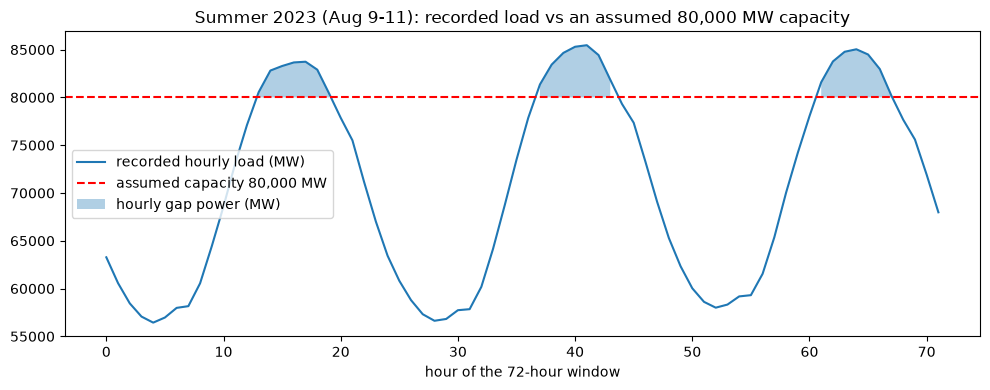

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(summer["recorded_load_mw"].values, label="recorded hourly load (MW)")
ax.axhline(CAPACITY, color="red", linestyle="--", label=f"assumed capacity {CAPACITY:,} MW")
above = summer["recorded_load_mw"] > CAPACITY
ax.fill_between(range(len(summer)), CAPACITY, summer["recorded_load_mw"], where=above,
                alpha=0.35, label="hourly gap power (MW)")
ax.set_title("Summer 2023 (Aug 9-11): recorded load vs an assumed 80,000 MW capacity")
ax.set_xlabel("hour of the 72-hour window")
ax.legend()
plt.tight_layout()
plt.show()